In [11]:
# ============================================================
# NOTEBOOK 08 — Sprint 6: Prueba con stakeholder y latencia
# Convertir a .ipynb con: jupytext --to notebook 08_stakeholder_latency.py
# ============================================================

# Sprint 6 — Prueba con stakeholder y latencia

**Sesión 12:** Prueba con stakeholder y latencia
**Meta:** validar utilidad (¿sirve para el usuario?)
y desempeño operativo (¿responde rápido / es estable?).

## 1. Setup y carga de modelos

In [12]:
import os, sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(project_root)
sys.path.insert(0, str(project_root / "src"))
print(f"Directorio de trabajo: {project_root}")

Directorio de trabajo: D:\MAESTRÍA AI - UNI\IV SEMESTRE\PROYECTO DE INVESTIGACIÓN II\WORKSPACE_GIT\posture-risk-mining_by_Huaytalla


In [13]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
warnings.filterwarnings("ignore", category=UserWarning, module="joblib")

In [14]:
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from loguru import logger as log

from posture_risk.experiments import (
    load_processed_h5, build_random_forest,
)
from posture_risk.experiments.ablations import (
    HPO_WINNER_PARAMS, build_xgb_with_scaler,
)
from posture_risk.analysis import (
    fit_isotonic_calibrators, apply_isotonic_calibration,
    find_optimal_thresholds, apply_thresholds,
)
from posture_risk.latency import (
    SLOs, evaluate_all_slos, export_slo_report,
    measure_stage_latency, measure_pipeline_latency, measure_throughput,
    format_latency_table,
    run_pruning_experiment,
)

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

SEED = 42
REPORTS_DIR = Path("reports")
FIGURES_DIR = REPORTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

### 1.1 Cargar datos y predicciones OOF del Sprint 5

In [15]:
X, y, subject_ids = load_processed_h5(Path("data/processed/pamap2_features.h5"))
print(f"Dataset: X={X.shape}, y={y.shape}")

oof_path = REPORTS_DIR / "oof_predictions.npz"
oof_data = np.load(oof_path)
y_pred_oof  = oof_data["y_pred"]
y_proba_oof = oof_data["y_proba"]

# Reajustar calibradores y umbrales sobre OOF (como en Sprint 5)
calibrators = fit_isotonic_calibrators(y_true=y, y_proba=y_proba_oof, n_classes=3)
thresholds  = find_optimal_thresholds(
    y_true=y, y_proba=y_proba_oof, metric="f1",
    class_priority={0: 1.0, 1: 1.0, 2: 1.5},
)
print(f"Umbrales óptimos: {thresholds}")

2026-07-10 18:17:24.346 | INFO     | posture_risk.experiments.ab_runner:load_processed_h5:47 - Dataset base: X=(194205, 297), y=(194205,), sujetos=[1 2 3 4 5 6 7 8 9]


Dataset: X=(194205, 297), y=(194205,)
Umbrales óptimos: {0: 0.36110740900039673, 1: 0.5693613290786743, 2: 0.49479949474334717}


### 1.2 Entrenar los modelos para las mediciones de latencia

In [16]:
log.info("Entrenando baseline RF...")
baseline_pipeline = build_random_forest(seed=SEED, n_estimators=200)
baseline_pipeline.fit(X, y)

log.info("Entrenando modelo actual XGB HPO winner...")
actual_pipeline = build_xgb_with_scaler(HPO_WINNER_PARAMS, seed=SEED)
actual_pipeline.fit(X, y)

2026-07-10 18:17:24.794 | INFO     | __main__:<module>:1 - Entrenando baseline RF...
2026-07-10 18:19:20.188 | INFO     | __main__:<module>:5 - Entrenando modelo actual XGB HPO winner...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None


## 2. Declaración formal de los SLOs adoptados

In [17]:
print("\n" + "="*72)
print("SLOs ADOPTADOS PARA EL SISTEMA")
print("="*72)
for key, slo in SLOs.items():
    marker = " [CRÍTICO]" if slo.critical else ""
    print(f"\n  [{key}]{marker}")
    print(f"    {slo.name}")
    print(f"    Umbral: {slo.comparison} {slo.threshold} {slo.unit}")


SLOs ADOPTADOS PARA EL SISTEMA

  [latency_p95_ms] [CRÍTICO]
    Latencia p95 por ventana
    Umbral: less_than 200.0 ms

  [latency_p50_ms]
    Latencia p50 por ventana
    Umbral: less_than 100.0 ms

  [throughput_req_per_sec] [CRÍTICO]
    Throughput sostenido
    Umbral: greater_or_equal 5.0 predicciones/segundo

  [error_rate_pct] [CRÍTICO]
    Tasa de errores en inferencia
    Umbral: less_than 1.0 %

  [f1_macro_min] [CRÍTICO]
    F1-Macro mínimo
    Umbral: greater_or_equal 0.8 


## 3. Definición de pipelines por etapa

**Modelo actual (5 etapas):** preprocess → scale → infer_xgb → calibrate → threshold

**Baseline RF (3 etapas):** scale → infer_rf → argmax

In [18]:
xgb_scaler = actual_pipeline.named_steps["scaler"]
xgb_model  = actual_pipeline.named_steps["clf"]
rf_scaler  = baseline_pipeline.named_steps["scaler"]
rf_model   = baseline_pipeline.named_steps["clf"]

sample_input = X[100:101]   # 1 ventana de 297 features

def stage_preprocess(x): return x.astype(np.float32)
def stage_scale_xgb(x):  return xgb_scaler.transform(x)
def stage_infer_xgb(x):  return xgb_model.predict_proba(x)
def stage_calibrate(x):  return apply_isotonic_calibration(x, calibrators)
def stage_threshold(x):  return apply_thresholds(x, thresholds)

actual_stages = {
    "1_preprocess": stage_preprocess,
    "2_scale":      stage_scale_xgb,
    "3_infer_xgb":  stage_infer_xgb,
    "4_calibrate":  stage_calibrate,
    "5_threshold":  stage_threshold,
}

def stage_scale_rf(x): return rf_scaler.transform(x)
def stage_infer_rf(x): return rf_model.predict_proba(x)
def stage_argmax(x):   return np.argmax(x, axis=1)

baseline_stages = {
    "1_scale":    stage_scale_rf,
    "2_infer_rf": stage_infer_rf,
    "3_argmax":   stage_argmax,
}

## 4. Perfilado de latencia por etapa

In [19]:
log.info("Perfilado del modelo actual (5 etapas)...")
actual_lat = measure_pipeline_latency(
    stages=actual_stages, input_sample=sample_input,
    n_repeats=500, n_warmup=50,
)

log.info("Perfilado del baseline RF (3 etapas)...")
baseline_lat = measure_pipeline_latency(
    stages=baseline_stages, input_sample=sample_input,
    n_repeats=500, n_warmup=50,
)

print(format_latency_table(actual_lat,   title="MODELO ACTUAL — Latencia por etapa"))
print(format_latency_table(baseline_lat, title="BASELINE RF   — Latencia por etapa"))

2026-07-10 18:20:11.467 | INFO     | __main__:<module>:1 - Perfilado del modelo actual (5 etapas)...
2026-07-10 18:20:11.469 | INFO     | posture_risk.latency.latency_measurement:measure_pipeline_latency:102 - Midiendo etapa: 1_preprocess
2026-07-10 18:20:11.476 | INFO     | posture_risk.latency.latency_measurement:measure_pipeline_latency:102 - Midiendo etapa: 2_scale
2026-07-10 18:20:11.639 | INFO     | posture_risk.latency.latency_measurement:measure_pipeline_latency:102 - Midiendo etapa: 3_infer_xgb
2026-07-10 18:20:12.122 | INFO     | posture_risk.latency.latency_measurement:measure_pipeline_latency:102 - Midiendo etapa: 4_calibrate
2026-07-10 18:20:12.704 | INFO     | posture_risk.latency.latency_measurement:measure_pipeline_latency:102 - Midiendo etapa: 5_threshold
2026-07-10 18:20:12.711 | INFO     | posture_risk.latency.latency_measurement:measure_pipeline_latency:122 - Midiendo pipeline completo end-to-end
2026-07-10 18:20:13.992 | INFO     | __main__:<module>:7 - Perfilado d


MODELO ACTUAL — Latencia por etapa
Etapa                            p50        p95        p99       mean      std
---------------------------------------------------------------------------
1_preprocess                0.003 ms   0.004 ms   0.010 ms   0.004 ms 0.009 ms
2_scale                     0.270 ms   0.437 ms   0.528 ms   0.285 ms 0.118 ms
3_infer_xgb                 0.779 ms   0.942 ms   1.123 ms   0.863 ms 1.389 ms
4_calibrate                 1.046 ms   1.377 ms   1.569 ms   1.055 ms 0.196 ms
5_threshold                 0.003 ms   0.009 ms   0.015 ms   0.005 ms 0.008 ms
---------------------------------------------------------------------------
TOTAL (end-to-end)          2.154 ms   2.811 ms   3.394 ms   2.287 ms 0.330 ms

BASELINE RF   — Latencia por etapa
Etapa                            p50        p95        p99       mean      std
---------------------------------------------------------------------------
1_scale                     0.222 ms   0.379 ms   0.468 ms   0.232 m

## 5. Throughput sostenido (10 segundos)

In [20]:
def full_actual_pipeline(x):
    x = stage_preprocess(x); x = stage_scale_xgb(x); x = stage_infer_xgb(x)
    x = stage_calibrate(x);  x = stage_threshold(x)
    return x

def full_baseline_pipeline(x):
    x = stage_scale_rf(x); x = stage_infer_rf(x); x = stage_argmax(x)
    return x

throughput_samples = [X[i:i+1] for i in range(100)]

log.info("Midiendo throughput sostenido — modelo actual...")
throughput_actual = measure_throughput(
    pipeline_fn=full_actual_pipeline, input_samples=throughput_samples,
    duration_s=10.0, n_warmup=100,
)

log.info("Midiendo throughput sostenido — baseline...")
throughput_baseline = measure_throughput(
    pipeline_fn=full_baseline_pipeline, input_samples=throughput_samples,
    duration_s=10.0, n_warmup=100,
)

print("\n" + "="*60)
print("THROUGHPUT SOSTENIDO (10 segundos)")
print("="*60)
print(f"  Modelo actual: {throughput_actual['throughput_rps']:>8.1f} pred/s")
print(f"  Baseline RF:   {throughput_baseline['throughput_rps']:>8.1f} pred/s")

2026-07-10 18:21:56.278 | INFO     | __main__:<module>:12 - Midiendo throughput sostenido — modelo actual...
2026-07-10 18:22:06.578 | INFO     | __main__:<module>:18 - Midiendo throughput sostenido — baseline...



THROUGHPUT SOSTENIDO (10 segundos)
  Modelo actual:    465.8 pred/s
  Baseline RF:       10.9 pred/s


## 6. Optimización: poda del ensemble XGBoost

2026-07-10 18:22:25.827 | INFO     | __main__:<module>:1 - Ejecutando experimento de poda (puede tardar ~15 minutos)...
2026-07-10 18:22:25.830 | INFO     | posture_risk.latency.pruning:run_pruning_experiment:120 - Iniciando experimento de poda con grid=[25, 50, 75, 100, 125, 150, 175, 200]
2026-07-10 18:22:25.832 | INFO     | posture_risk.latency.pruning:run_pruning_experiment:124 - Evaluando n_estimators=25...
2026-07-10 18:23:00.984 | INFO     | posture_risk.latency.pruning:run_pruning_experiment:124 - Evaluando n_estimators=50...
2026-07-10 18:23:57.605 | INFO     | posture_risk.latency.pruning:run_pruning_experiment:124 - Evaluando n_estimators=75...
2026-07-10 18:25:12.316 | INFO     | posture_risk.latency.pruning:run_pruning_experiment:124 - Evaluando n_estimators=100...
2026-07-10 18:26:47.321 | INFO     | posture_risk.latency.pruning:run_pruning_experiment:124 - Evaluando n_estimators=125...
2026-07-10 18:28:41.702 | INFO     | posture_risk.latency.pruning:run_pruning_experime


EXPERIMENTO DE PODA DEL ENSEMBLE XGBOOST
 n_arboles        F1-Macro Latencia p50 (ms) Latencia p95 (ms)
        25 0.8473 ± 0.0203             1.203             1.478
        50 0.8593 ± 0.0203             1.315             1.526
        75 0.8646 ± 0.0202             1.119             1.235
       100 0.8683 ± 0.0196             1.121             1.335
       125 0.8704 ± 0.0193             1.289             1.597
       150 0.8713 ± 0.0197             1.238             1.610
       175 0.8729 ± 0.0194             1.149             1.258
       200 0.8741 ± 0.0190             1.181             1.359

Selección: n_estimators = 75
  F1-Macro:     0.8646
  Latencia p95: 1.235 ms
  Reducción latencia p95 vs 200 árboles: 9.1%


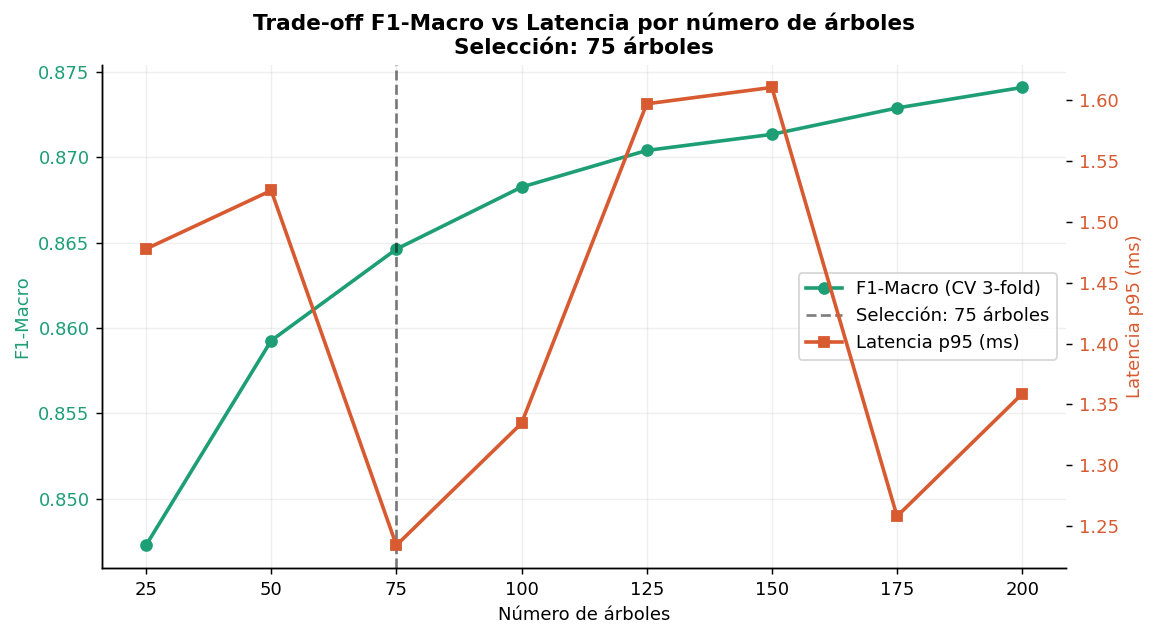

In [21]:
log.info("Ejecutando experimento de poda (puede tardar ~15 minutos)...")
pruning_results = run_pruning_experiment(
    X, y, subject_ids,
    n_estimator_grid=[25, 50, 75, 100, 125, 150, 175, 200],
    n_folds=3, seed=SEED, max_f1_loss=0.01,
)

pruning_df = pd.DataFrame([
    {
        "n_arboles": v["n_estimators"],
        "F1-Macro":  f"{v['f1_macro_mean']:.4f} ± {v['f1_macro_std']:.4f}",
        "Latencia p50 (ms)": f"{v['latency_p50_ms']:.3f}",
        "Latencia p95 (ms)": f"{v['latency_p95_ms']:.3f}",
    }
    for v in pruning_results["variants"].values()
]).sort_values("n_arboles").reset_index(drop=True)

print("\n" + "="*70)
print("EXPERIMENTO DE PODA DEL ENSEMBLE XGBOOST")
print("="*70)
print(pruning_df.to_string(index=False))
print(f"\nSelección: n_estimators = {pruning_results['selected_n_estimators']}")
print(f"  F1-Macro:     {pruning_results['selected_f1']:.4f}")
print(f"  Latencia p95: {pruning_results['selected_latency_p95']:.3f} ms")
if pruning_results['latency_reduction_pct'] is not None:
    print(f"  Reducción latencia p95 vs 200 árboles: "
          f"{pruning_results['latency_reduction_pct']:.1f}%")

# Gráfico F1 vs latencia
fig, ax1 = plt.subplots(figsize=(9, 5))
n_ests = sorted(pruning_results["variants"].keys())
f1s    = [pruning_results["variants"][n]["f1_macro_mean"] for n in n_ests]
lats   = [pruning_results["variants"][n]["latency_p95_ms"] for n in n_ests]

ax1.plot(n_ests, f1s, "o-", color="#1D9E75", lw=2, label="F1-Macro (CV 3-fold)")
ax1.set_xlabel("Número de árboles")
ax1.set_ylabel("F1-Macro", color="#1D9E75")
ax1.tick_params(axis="y", labelcolor="#1D9E75")
ax1.grid(alpha=0.2)

ax2 = ax1.twinx()
ax2.plot(n_ests, lats, "s-", color="#D85A30", lw=2, label="Latencia p95 (ms)")
ax2.set_ylabel("Latencia p95 (ms)", color="#D85A30")
ax2.tick_params(axis="y", labelcolor="#D85A30")

sel = pruning_results["selected_n_estimators"]
ax1.axvline(sel, color="black", ls="--", alpha=0.5,
            label=f"Selección: {sel} árboles")

ax1.set_title(f"Trade-off F1-Macro vs Latencia por número de árboles\n"
              f"Selección: {sel} árboles",
              fontweight="bold")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")
plt.tight_layout()
fig_path = FIGURES_DIR / "21_pruning_tradeoff.png"
plt.savefig(fig_path, bbox_inches="tight", dpi=150)
plt.show()

## 7. A/B controlado simulado sobre las 194,205 ventanas

In [22]:
from sklearn.metrics import f1_score, precision_score, recall_score

y_proba_oof_cal = apply_isotonic_calibration(y_proba_oof, calibrators)
y_pred_actual = apply_thresholds(y_proba_oof_cal, thresholds)

log.info("Generando predicciones del baseline para A/B...")
y_pred_baseline = baseline_pipeline.predict(X)

def metric_bundle(y_true, y_pred, name):
    return {
        "modelo":  name,
        "F1-Macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Precision (alto)": precision_score(y_true, y_pred, labels=[2],
                                             average="macro", zero_division=0),
        "Recall (alto)": recall_score(y_true, y_pred, labels=[2],
                                       average="macro", zero_division=0),
    }

metrics_baseline = metric_bundle(y, y_pred_baseline, "Baseline RF")
metrics_actual   = metric_bundle(y, y_pred_actual,   "Modelo actual")

n_total = len(y)
alerts_baseline  = int((y_pred_baseline == 2).sum())
alerts_actual    = int((y_pred_actual == 2).sum())
false_positives_baseline = int(((y_pred_baseline == 2) & (y != 2)).sum())
false_positives_actual   = int(((y_pred_actual   == 2) & (y != 2)).sum())
missed_high_baseline = int(((y_pred_baseline != 2) & (y == 2)).sum())
missed_high_actual   = int(((y_pred_actual   != 2) & (y == 2)).sum())

# 1 hora = 3600 s × 5 pred/s = 18000 predicciones
alertas_por_hora_baseline = alerts_baseline / n_total * 18000
alertas_por_hora_actual   = alerts_actual   / n_total * 18000
falsas_alarmas_por_hora_baseline = false_positives_baseline / n_total * 18000
falsas_alarmas_por_hora_actual   = false_positives_actual   / n_total * 18000

print("\n" + "="*75)
print("A/B CONTROLADO SIMULADO (194,205 ventanas)")
print("="*75)
print(f"\nMétricas técnicas:")
print(f"  {'Métrica':<25} {'Baseline':>13} {'Actual':>13}   Δ")
for k in ["F1-Macro", "Precision (alto)", "Recall (alto)"]:
    v_base = metrics_baseline[k]
    v_act  = metrics_actual[k]
    print(f"  {k:<25} {v_base:>13.4f} {v_act:>13.4f}   {v_act-v_base:+.4f}")

print(f"\nProyección por hora de operación (5 pred/s):")
print(f"  Alertas emitidas/hora:  "
      f"{alertas_por_hora_baseline:>10.1f}   {alertas_por_hora_actual:>10.1f}")
print(f"  Falsas alarmas/hora:    "
      f"{falsas_alarmas_por_hora_baseline:>10.1f}   {falsas_alarmas_por_hora_actual:>10.1f}")

2026-07-10 18:36:17.896 | INFO     | __main__:<module>:6 - Generando predicciones del baseline para A/B...



A/B CONTROLADO SIMULADO (194,205 ventanas)

Métricas técnicas:
  Métrica                        Baseline        Actual   Δ
  F1-Macro                         0.9747        0.8868   -0.0878
  Precision (alto)                 0.9359        0.8618   -0.0741
  Recall (alto)                    0.9895        0.8831   -0.1064

Proyección por hora de operación (5 pred/s):
  Alertas emitidas/hora:      4538.3       4398.8
  Falsas alarmas/hora:         290.8        607.9


## 8. Evaluación de SLOs

In [23]:
measurements = {
    "latency_p95_ms":         actual_lat["total"]["p95_ms"],
    "latency_p50_ms":         actual_lat["total"]["p50_ms"],
    "throughput_req_per_sec": throughput_actual["throughput_rps"],
    "error_rate_pct":         actual_lat["total"]["error_rate_pct"],
    "f1_macro_min":           metrics_actual["F1-Macro"],
}

slo_report = evaluate_all_slos(measurements)

print("\n" + "="*72)
print("EVALUACIÓN DE SLOs")
print("="*72)
for key, res in slo_report["slos"].items():
    icon = "PASS" if res["passed"] else "FAIL"
    crit = " [CRÍTICO]" if res.get("critical") else ""
    print(f"\n  [{icon}]{crit} {res['slo_name']}")
    print(f"      Umbral: {res['comparison']} {res['threshold']} {res['unit']}")
    print(f"      Medido: {res['measured']:.3f} {res['unit']}")

print(f"\n{'='*72}")
if slo_report["deployment_ready"]:
    print("VEREDICTO: sistema APTO para despliegue (todos los SLOs críticos pasan)")
else:
    print("VEREDICTO: sistema NO APTO. SLOs críticos que fallan:")
    for s in slo_report["critical_failing"]:
        print(f"   • {s}")


EVALUACIÓN DE SLOs

  [PASS] [CRÍTICO] Latencia p95 por ventana
      Umbral: less_than 200.0 ms
      Medido: 2.811 ms

  [PASS] Latencia p50 por ventana
      Umbral: less_than 100.0 ms
      Medido: 2.154 ms

  [PASS] [CRÍTICO] Throughput sostenido
      Umbral: greater_or_equal 5.0 predicciones/segundo
      Medido: 465.837 predicciones/segundo

  [PASS] [CRÍTICO] Tasa de errores en inferencia
      Umbral: less_than 1.0 %
      Medido: 0.000 %

  [PASS] [CRÍTICO] F1-Macro mínimo
      Umbral: greater_or_equal 0.8 
      Medido: 0.887 

VEREDICTO: sistema APTO para despliegue (todos los SLOs críticos pasan)


## 9. Tabla comparativa final baseline vs actual

In [24]:
comparison_table = pd.DataFrame([
    {"Métrica": "F1-Macro (CV LOSO)", "Baseline RF": "0.7942 ± 0.2003",
     "Modelo actual": f"{metrics_actual['F1-Macro']:.4f}"},
    {"Métrica": "Recall clase Alto",
     "Baseline RF": f"{metrics_baseline['Recall (alto)']:.4f}",
     "Modelo actual": f"{metrics_actual['Recall (alto)']:.4f}"},
    {"Métrica": "Latencia p50 (ms)",
     "Baseline RF": f"{baseline_lat['total']['p50_ms']:.3f}",
     "Modelo actual": f"{actual_lat['total']['p50_ms']:.3f}"},
    {"Métrica": "Latencia p95 (ms)",
     "Baseline RF": f"{baseline_lat['total']['p95_ms']:.3f}",
     "Modelo actual": f"{actual_lat['total']['p95_ms']:.3f}"},
    {"Métrica": "Latencia p99 (ms)",
     "Baseline RF": f"{baseline_lat['total']['p99_ms']:.3f}",
     "Modelo actual": f"{actual_lat['total']['p99_ms']:.3f}"},
    {"Métrica": "Throughput (pred/s)",
     "Baseline RF": f"{throughput_baseline['throughput_rps']:.1f}",
     "Modelo actual": f"{throughput_actual['throughput_rps']:.1f}"},
    {"Métrica": "Falsas alarmas/hora",
     "Baseline RF": f"{falsas_alarmas_por_hora_baseline:.1f}",
     "Modelo actual": f"{falsas_alarmas_por_hora_actual:.1f}"},
])

print("\n" + "="*80)
print("COMPARATIVO BASELINE vs MODELO ACTUAL")
print("="*80)
print(comparison_table.to_string(index=False))

comparison_table.to_csv(REPORTS_DIR / "sprint6_comparison.csv", index=False)


COMPARATIVO BASELINE vs MODELO ACTUAL
            Métrica     Baseline RF Modelo actual
 F1-Macro (CV LOSO) 0.7942 ± 0.2003        0.8868
  Recall clase Alto          0.9895        0.8831
  Latencia p50 (ms)          91.408         2.154
  Latencia p95 (ms)         101.250         2.811
  Latencia p99 (ms)         112.730         3.394
Throughput (pred/s)            10.9         465.8
Falsas alarmas/hora           290.8         607.9


## 10. Persistencia

In [25]:
final_report = {
    "slos":              slo_report,
    "latency_baseline":  baseline_lat,
    "latency_actual":    actual_lat,
    "throughput_baseline": throughput_baseline,
    "throughput_actual":   throughput_actual,
    "pruning": {
        "baseline_n_est":       200,
        "baseline_f1":          pruning_results["baseline_f1"],
        "baseline_latency_p95": pruning_results["baseline_latency_p95"],
        "selected_n_est":       pruning_results["selected_n_estimators"],
        "selected_f1":          pruning_results["selected_f1"],
        "selected_latency_p95": pruning_results["selected_latency_p95"],
        "latency_reduction_pct": pruning_results["latency_reduction_pct"],
    },
    "ab_comparison": {
        "metrics_baseline": metrics_baseline,
        "metrics_actual":   metrics_actual,
        "false_alarms_per_hour_baseline": falsas_alarmas_por_hora_baseline,
        "false_alarms_per_hour_actual":   falsas_alarmas_por_hora_actual,
    },
}

with open(REPORTS_DIR / "sprint6_summary.json", "w") as f:
    json.dump(final_report, f, indent=2, default=str)

export_slo_report(slo_report, REPORTS_DIR / "sprint6_slo_report.json")

print(f"\nArtefactos generados:")
print(f"  • {REPORTS_DIR / 'sprint6_summary.json'}")
print(f"  • {REPORTS_DIR / 'sprint6_slo_report.json'}")
print(f"  • {REPORTS_DIR / 'sprint6_comparison.csv'}")
print(f"  • {fig_path}")


Artefactos generados:
  • reports\sprint6_summary.json
  • reports\sprint6_slo_report.json
  • reports\sprint6_comparison.csv
  • reports\figures\21_pruning_tradeoff.png
